In [21]:
# 1. 导入需要用到的工具库
# 数据集、划分数据集、SVM模型、精度计算、绘图库
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [22]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 优先使用支持中文的字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

In [23]:
# 2. 加载鸢尾花数据集
iris = load_iris()
X = iris.data[:, [1, 2]]   # 只挑选2个特征，满足二维可视化要求
# 完整标签：0、1、2 三类鸢尾花，做多分类
y = iris.target

In [24]:
# 3. 划分训练集、测试集
# 80%训练数据用来训练模型，20%测试数据用来检测准确率
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 测试数据占比20%
    random_state=42  # 固定随机数，每次运行结果一致
)

In [25]:
# 4. 定义绘制决策边界函数
def plot_decision_boundary(x_data, y_data, model):
    # 获取坐标最大最小值，扩大范围画出完整边界
    x_min, x_max = x_data[:, 0].min() - 1, x_data[:, 0].max() + 1
    y_min, y_max = x_data[:, 1].min() - 1, x_data[:, 1].max() + 1
    # 生成密集网格点
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    # 模型预测所有网格点类别
    z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)
    # 绘制分类色块
    plt.contourf(xx, yy, z, alpha=0.4)
    # 绘制原始样本散点
    plt.scatter(x_data[:, 0], x_data[:, 1], c=y_data, edgecolors='k')
    plt.title("SVM 鸢尾花多分类决策边界")
    plt.xlabel("特征1")
    plt.ylabel("特征2")
    plt.show()

In [26]:
# 5. 创建SVM支持向量机模型
svm_model = SVC(kernel='linear')  # 线性核函数

In [27]:
# 6. 模型训练：用训练集数据学习分类规则
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [28]:
# 7. 测试集预测结果
y_predict = svm_model.predict(X_test)

In [29]:
# 8. 计算分类准确率
acc = accuracy_score(y_test, y_predict)
print("模型测试集分类准确率：", acc)

模型测试集分类准确率： 1.0


In [30]:
# 9. 输出SVM核心参数
print("SVM权重系数：\n", svm_model.coef_)
print("SVM偏置项：\n", svm_model.intercept_)

SVM权重系数：
 [[ 0.6687899  -1.2261146 ]
 [ 0.23778066 -0.68692192]
 [ 1.21468542 -3.0319981 ]]
SVM偏置项：
 [ 1.05573186  1.49669717 11.18307316]


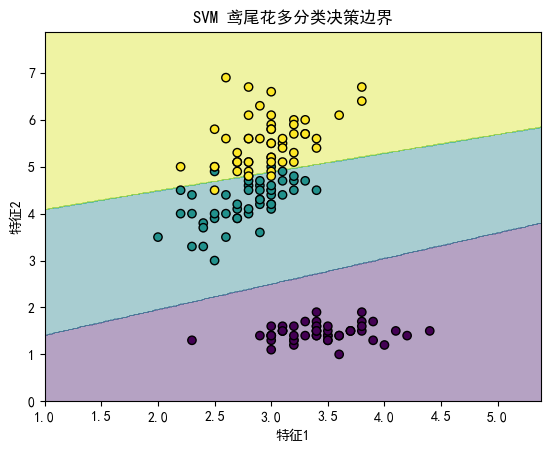

In [31]:
# 10. 绘制可视化决策边界
plot_decision_boundary(X, y, svm_model)